In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = "/kaggle/working/"

In [2]:
all_results = [

    # ── Classical ML ─────────────────────────────────────────
    {'Category': 'Classical ML',
     'Model': 'Logistic Regression',
     'EN_Test_F1': 0.792,
     'BN_Test_F1': 0.758,
     'EN_Sarc_F1': 0.790,
     'BN_Sarc_F1': 0.651,
     'Note': 'TF-IDF + 15 stylistic features'},

    {'Category': 'Classical ML',
     'Model': 'SVM (LinearSVC)',
     'EN_Test_F1': 0.806,
     'BN_Test_F1': 0.759,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': None,
     'Note': 'Val F1 only — not re-run on test'},

    # ── Deep Learning ─────────────────────────────────────────
    {'Category': 'Deep Learning',
     'Model': 'LSTM',
     'EN_Test_F1': None,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.80,
     'BN_Sarc_F1': 0.50,
     'Note': 'Val F1: EN 0.797, BN 0.655'},

    {'Category': 'Deep Learning',
     'Model': 'BiLSTM',
     'EN_Test_F1': 0.824,
     'BN_Test_F1': 0.762,
     'EN_Sarc_F1': 0.823,
     'BN_Sarc_F1': 0.645,
     'Note': 'Best deep learning model'},

    {'Category': 'Deep Learning',
     'Model': 'CNN',
     'EN_Test_F1': None,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.78,
     'BN_Sarc_F1': 0.62,
     'Note': 'Val F1: EN 0.790, BN 0.743'},

    # ── Transformer Baselines ─────────────────────────────────
    {'Category': 'Transformer (Single-task)',
     'Model': 'BERT',
     'EN_Test_F1': 0.903,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.920,
     'BN_Sarc_F1': None,
     'Note': 'English only — bert-base-uncased'},

    {'Category': 'Transformer (Single-task)',
     'Model': 'DistilBERT',
     'EN_Test_F1': 0.894,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.900,
     'BN_Sarc_F1': None,
     'Note': 'English only — ~40% fewer params'},

    {'Category': 'Transformer (Single-task)',
     'Model': 'BanglaBERT',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.820,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.740,
     'Note': 'Bangla only — csebuetnlp/banglabert'},

    {'Category': 'Transformer (Single-task)',
     'Model': 'mBERT',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.774,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.670,
     'Note': 'Bangla only — multilingual BERT'},

    # ── Dual-Head Framework ───────────────────────────────────
    {'Category': 'Dual-Head XLM-RoBERTa (Proposed)',
     'Model': 'XLM-RoBERTa Dual-Head (English)',
     'EN_Test_F1': 0.8983,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.910,
     'BN_Sarc_F1': None,
     'Note': 'Hate + Sarcasm heads, shared encoder'},

    {'Category': 'Dual-Head XLM-RoBERTa (Proposed)',
     'Model': 'XLM-RoBERTa Dual-Head (Bangla)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.8151,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.720,
     'Note': 'Hate + Sarcasm heads, shared encoder'},

    # ── Lightweight Dual-Head ─────────────────────────────────
    {'Category': 'Lightweight Dual-Head',
     'Model': 'DistilBERT Dual-Head (English)',
     'EN_Test_F1': 0.8927,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.910,
     'BN_Sarc_F1': None,
     'Note': '~40% fewer params, same dual-head design'},

    {'Category': 'Lightweight Dual-Head',
     'Model': 'mDistilBERT Dual-Head (Bangla)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.7919,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.660,
     'Note': 'Multilingual DistilBERT backbone'},

    # ── Ablation Study ────────────────────────────────────────
    {'Category': 'Ablation Study',
     'Model': 'XLM-RoBERTa — No Hate Head (English)',
     'EN_Test_F1': 0.8976,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.910,
     'BN_Sarc_F1': None,
     'Note': 'Sarcasm head only'},

    {'Category': 'Ablation Study',
     'Model': 'XLM-RoBERTa — No Sarcasm Head (English)',
     'EN_Test_F1': 0.8962,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.900,
     'BN_Sarc_F1': None,
     'Note': 'Hate head only — lowest EN'},

    {'Category': 'Ablation Study',
     'Model': 'XLM-RoBERTa — Single-Task (English)',
     'EN_Test_F1': 0.8993,
     'BN_Test_F1': None,
     'EN_Sarc_F1': 0.910,
     'BN_Sarc_F1': None,
     'Note': 'No auxiliary heads'},

    {'Category': 'Ablation Study',
     'Model': 'XLM-RoBERTa — No Hate Head (Bangla)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.8097,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.700,
     'Note': 'Sarcasm head only'},

    {'Category': 'Ablation Study',
     'Model': 'XLM-RoBERTa — No Sarcasm Head (Bangla)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.8055,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.690,
     'Note': 'Hate head only — lowest BN'},

    {'Category': 'Ablation Study',
     'Model': 'XLM-RoBERTa — Single-Task (Bangla)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.8092,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': 0.690,
     'Note': 'No auxiliary heads'},

    # ── Transfer Learning ─────────────────────────────────────
    {'Category': 'Transfer Learning',
     'Model': 'English model → Bangla test (zero-shot)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.2633,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': None,
     'Note': 'Complete failure — no Bangla exposure'},

    {'Category': 'Transfer Learning',
     'Model': 'Bangla model → English test (zero-shot)',
     'EN_Test_F1': 0.3346,
     'BN_Test_F1': None,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': None,
     'Note': 'Complete failure — no English exposure'},

    {'Category': 'Transfer Learning',
     'Model': 'English model + 10% Bangla → Bangla test (few-shot)',
     'EN_Test_F1': None,
     'BN_Test_F1': 0.7332,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': None,
     'Note': '89% of BanglaBERT F1 with only 10% data'},

    # ── External Dataset ──────────────────────
    {'Category': 'Concept Drift',
     'Model': 'XLM-RoBERTa Dual-Head → OLID 2019 (zero-shot)',
     'EN_Test_F1': 0.5814,
     'BN_Test_F1': None,
     'EN_Sarc_F1': None,
     'BN_Sarc_F1': None,
     'Note': '35.6% relative drop — concept drift confirmed'},
]

df_all = pd.DataFrame(all_results)

# Format for display
def fmt(v):
    return f"{v:.4f}" if v is not None else "—"

df_display = df_all.copy()
for col in ['EN_Test_F1','BN_Test_F1','EN_Sarc_F1','BN_Sarc_F1']:
    df_display[col] = df_all[col].apply(fmt)

print("=" * 100)
print("COMPLETE RESULTS — ALL EXPERIMENTS")
print("=" * 100)
print(df_display[['Category','Model','EN_Test_F1',
                   'BN_Test_F1','EN_Sarc_F1','BN_Sarc_F1']].to_string(index=False))
df_all.to_csv(f"{OUTPUT_DIR}MASTER_RESULTS_ALL_EXPERIMENTS.csv", index=False)

COMPLETE RESULTS — ALL EXPERIMENTS
                        Category                                               Model EN_Test_F1 BN_Test_F1 EN_Sarc_F1 BN_Sarc_F1
                    Classical ML                                 Logistic Regression     0.7920     0.7580     0.7900     0.6510
                    Classical ML                                     SVM (LinearSVC)     0.8060     0.7590        nan        nan
                   Deep Learning                                                LSTM        nan        nan     0.8000     0.5000
                   Deep Learning                                              BiLSTM     0.8240     0.7620     0.8230     0.6450
                   Deep Learning                                                 CNN        nan        nan     0.7800     0.6200
       Transformer (Single-task)                                                BERT     0.9030        nan     0.9200        nan
       Transformer (Single-task)                              

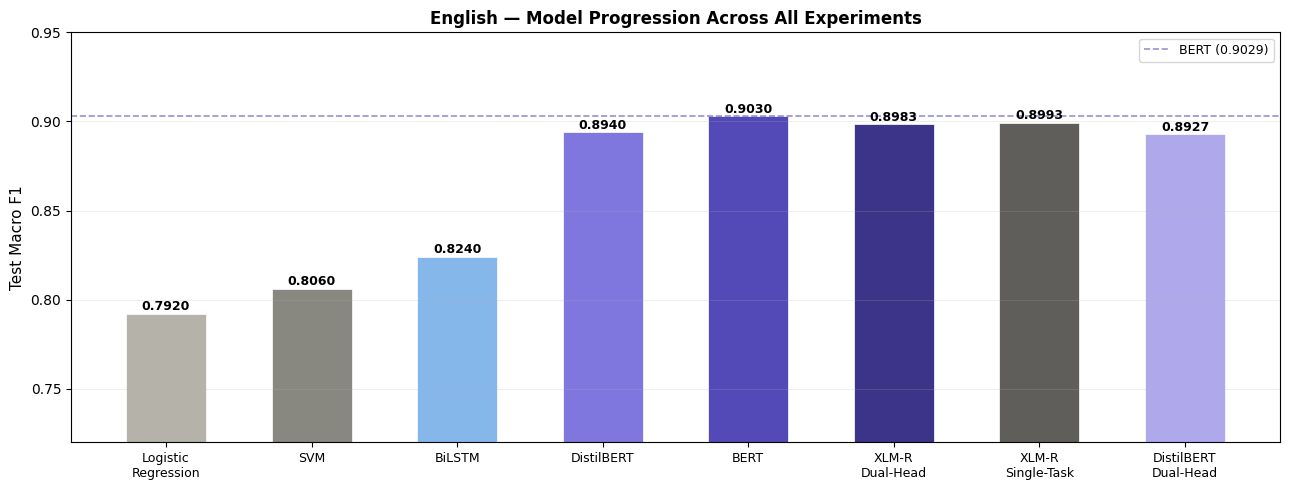

In [3]:
# Best representative model per category for English
en_progression = [
    ('Logistic\nRegression',   0.792,  '#B4B2A9'),
    ('SVM',                    0.806,  '#888780'),
    ('BiLSTM',                 0.824,  '#85B7EB'),
    ('DistilBERT',             0.894,  '#7F77DD'),
    ('BERT',                   0.903,  '#534AB7'),
    ('XLM-R\nDual-Head',       0.8983, '#3C3489'),
    ('XLM-R\nSingle-Task',     0.8993, '#5F5E5A'),
    ('DistilBERT\nDual-Head',  0.8927, '#AFA9EC'),
]

fig, ax = plt.subplots(figsize=(13, 5))
labels = [d[0] for d in en_progression]
values = [d[1] for d in en_progression]
colors = [d[2] for d in en_progression]

bars = ax.bar(range(len(en_progression)), values,
              color=colors, width=0.55, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=0.903, color='#534AB7', linestyle='--',
           linewidth=1.2, alpha=0.6, label='BERT (0.9029)')
ax.set_xticks(range(len(en_progression)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Test Macro F1', fontsize=11)
ax.set_title('English — Model Progression Across All Experiments',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.72, 0.95)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}english_model_progression.png", dpi=150)
plt.show()

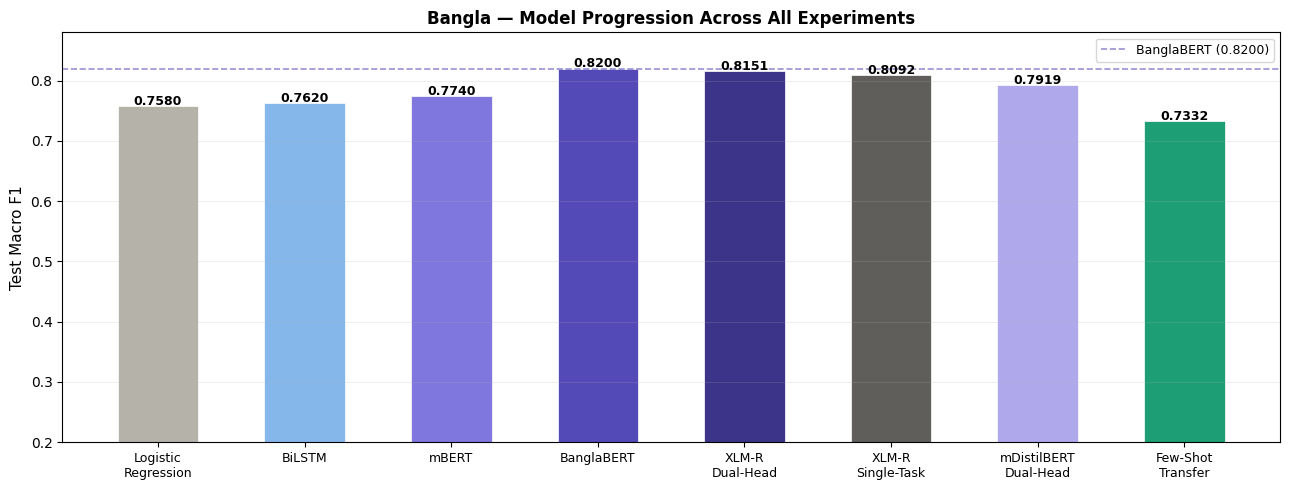

In [4]:
bn_progression = [
    ('Logistic\nRegression',    0.758,  '#B4B2A9'),
    ('BiLSTM',                  0.762,  '#85B7EB'),
    ('mBERT',                   0.774,  '#7F77DD'),
    ('BanglaBERT',              0.820,  '#534AB7'),
    ('XLM-R\nDual-Head',        0.8151, '#3C3489'),
    ('XLM-R\nSingle-Task',      0.8092, '#5F5E5A'),
    ('mDistilBERT\nDual-Head',  0.7919, '#AFA9EC'),
    ('Few-Shot\nTransfer',      0.7332, '#1D9E75'),
]

fig, ax = plt.subplots(figsize=(13, 5))
labels = [d[0] for d in bn_progression]
values = [d[1] for d in bn_progression]
colors = [d[2] for d in bn_progression]

bars = ax.bar(range(len(bn_progression)), values,
              color=colors, width=0.55, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=0.820, color='#534AB7', linestyle='--',
           linewidth=1.2, alpha=0.6, label='BanglaBERT (0.8200)')
ax.set_xticks(range(len(bn_progression)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Test Macro F1', fontsize=11)
ax.set_title('Bangla — Model Progression Across All Experiments',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.20, 0.88)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}bangla_model_progression.png", dpi=150)
plt.show()

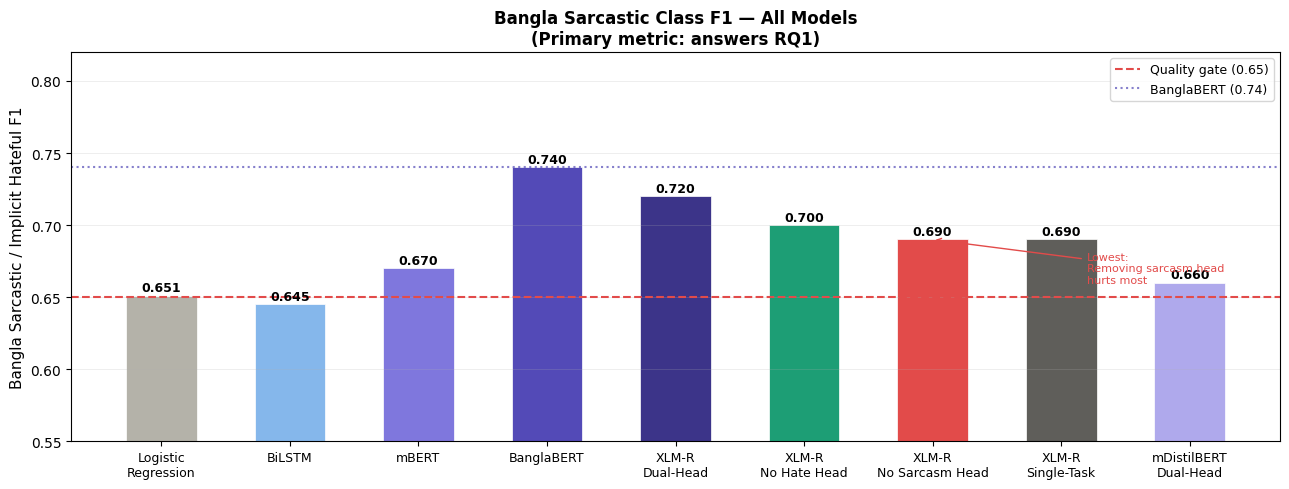

In [5]:
bn_sarc = [
    ('Logistic\nRegression',          0.651, '#B4B2A9'),
    ('BiLSTM',                        0.645, '#85B7EB'),
    ('mBERT',                         0.670, '#7F77DD'),
    ('BanglaBERT',                    0.740, '#534AB7'),
    ('XLM-R\nDual-Head',              0.720, '#3C3489'),
    ('XLM-R\nNo Hate Head',           0.700, '#1D9E75'),
    ('XLM-R\nNo Sarcasm Head',        0.690, '#E24B4A'),
    ('XLM-R\nSingle-Task',            0.690, '#5F5E5A'),
    ('mDistilBERT\nDual-Head',        0.660, '#AFA9EC'),
]

fig, ax = plt.subplots(figsize=(13, 5))
labels = [d[0] for d in bn_sarc]
values = [d[1] for d in bn_sarc]
colors = [d[2] for d in bn_sarc]

bars = ax.bar(range(len(bn_sarc)), values,
              color=colors, width=0.55, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=0.65, color='#E24B4A', linestyle='--',
           linewidth=1.5, label='Quality gate (0.65)')
ax.axhline(y=0.74, color='#534AB7', linestyle=':',
           linewidth=1.5, alpha=0.7, label='BanglaBERT (0.74)')

# Highlight that No Sarcasm Head is the lowest
ax.annotate('Lowest:\nRemoving sarcasm head\nhurts most',
            xy=(6, 0.690), xytext=(7.2, 0.660),
            arrowprops=dict(arrowstyle='->', color='#E24B4A'),
            fontsize=8, color='#E24B4A')

ax.set_xticks(range(len(bn_sarc)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Bangla Sarcastic / Implicit Hateful F1', fontsize=11)
ax.set_title('Bangla Sarcastic Class F1 — All Models\n'
             '(Primary metric: answers RQ1)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.55, 0.82)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}bangla_sarcastic_f1_all_models.png", dpi=150)
plt.show()

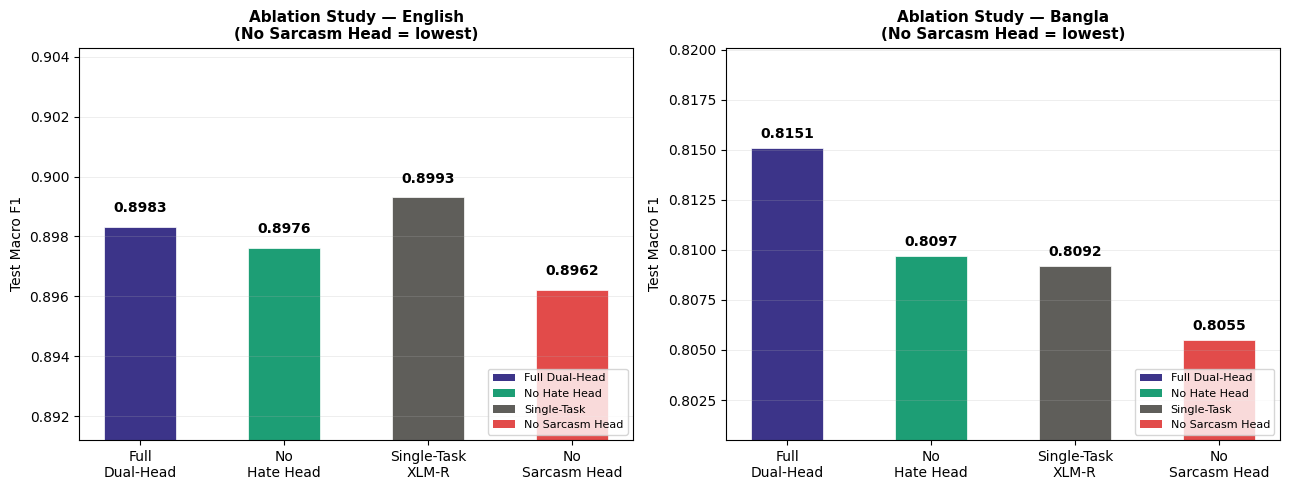

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, lang, data in [
    (axes[0], 'English', [
        ('Full\nDual-Head',   0.8983, '#3C3489'),
        ('No\nHate Head',     0.8976, '#1D9E75'),
        ('Single-Task\nXLM-R',0.8993, '#5F5E5A'),
        ('No\nSarcasm Head',  0.8962, '#E24B4A'),
    ]),
    (axes[1], 'Bangla', [
        ('Full\nDual-Head',   0.8151, '#3C3489'),
        ('No\nHate Head',     0.8097, '#1D9E75'),
        ('Single-Task\nXLM-R',0.8092, '#5F5E5A'),
        ('No\nSarcasm Head',  0.8055, '#E24B4A'),
    ]),
]:
    labels = [d[0] for d in data]
    values = [d[1] for d in data]
    colors = [d[2] for d in data]

    bars = ax.bar(range(len(data)), values,
                  color=colors, width=0.5,
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0005,
                f'{val:.4f}', ha='center',
                fontsize=10, fontweight='bold')

    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Test Macro F1', fontsize=10)
    ax.set_title(f'Ablation Study — {lang}\n'
                 f'(No Sarcasm Head = lowest)',
                 fontsize=11, fontweight='bold')
    bottom = min(values) - 0.005
    ax.set_ylim(bottom, max(values) + 0.005)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3C3489', label='Full Dual-Head'),
        Patch(facecolor='#1D9E75', label='No Hate Head'),
        Patch(facecolor='#5F5E5A', label='Single-Task'),
        Patch(facecolor='#E24B4A', label='No Sarcasm Head'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}ablation_both_languages.png", dpi=150)
plt.show()

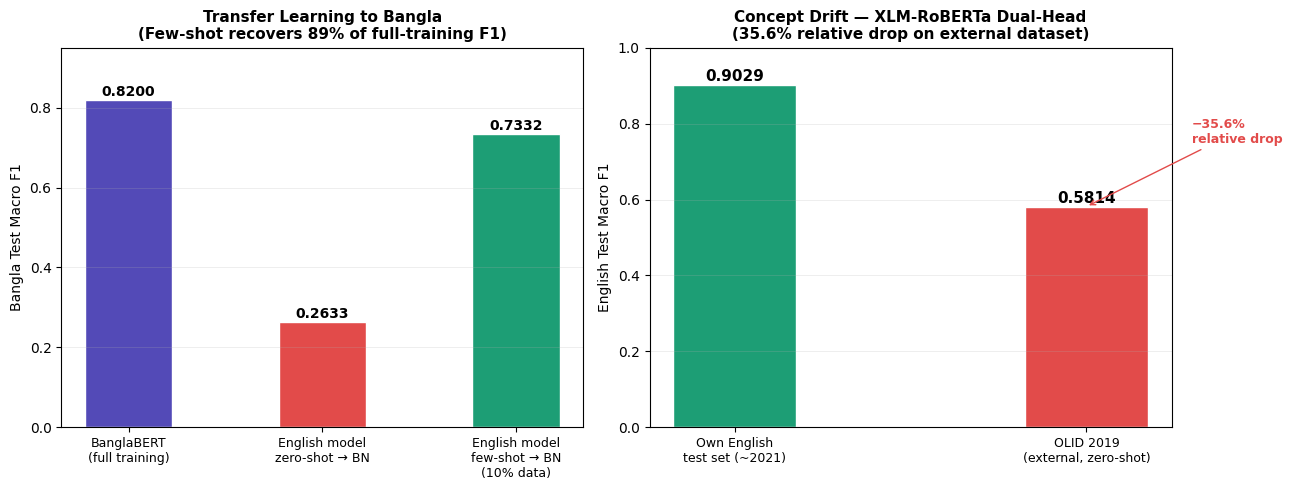

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Transfer learning
ax1 = axes[0]
tl_data = [
    ('BanglaBERT\n(full training)', 0.8200, '#534AB7', 'Baseline'),
    ('English model\nzero-shot → BN', 0.2633, '#E24B4A', 'Zero-shot'),
    ('English model\nfew-shot → BN\n(10% data)', 0.7332, '#1D9E75', 'Few-shot'),
]
bars = ax1.bar(range(len(tl_data)),
               [d[1] for d in tl_data],
               color=[d[2] for d in tl_data],
               width=0.45, edgecolor='white')
for bar, val in zip(bars, [d[1] for d in tl_data]):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_xticks(range(len(tl_data)))
ax1.set_xticklabels([d[0] for d in tl_data], fontsize=9)
ax1.set_ylabel('Bangla Test Macro F1', fontsize=10)
ax1.set_title('Transfer Learning to Bangla\n'
              '(Few-shot recovers 89% of full-training F1)',
              fontsize=11, fontweight='bold')
ax1.set_ylim(0, 0.95)
ax1.grid(axis='y', alpha=0.3, linewidth=0.5)

# Concept drift
ax2 = axes[1]
cd_data = [
    ('Own English\ntest set (~2021)',  0.9029, '#1D9E75'),
    ('OLID 2019\n(external, zero-shot)', 0.5814, '#E24B4A'),
]
bars2 = ax2.bar(range(len(cd_data)),
                [d[1] for d in cd_data],
                color=[d[2] for d in cd_data],
                width=0.35, edgecolor='white')
for bar, val in zip(bars2, [d[1] for d in cd_data]):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(cd_data)))
ax2.set_xticklabels([d[0] for d in cd_data], fontsize=9)
ax2.set_ylabel('English Test Macro F1', fontsize=10)
ax2.set_title('Concept Drift — XLM-RoBERTa Dual-Head\n'
              '(35.6% relative drop on external dataset)',
              fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.annotate('−35.6%\nrelative drop',
             xy=(1, 0.5814), xytext=(1.3, 0.75),
             arrowprops=dict(arrowstyle='->', color='#E24B4A'),
             fontsize=9, color='#E24B4A', fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}transfer_and_concept_drift.png", dpi=150)
plt.show()